**Code for training semantic segmentation models using the SMP library**

Import Libraries

In [1]:
import os
import numpy as np
from tqdm import tqdm
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

Hyperparameters

In [2]:
MODEL_NAME = "manet" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d" 
DEVICE_ID = 1
EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 64
IMAGE_SIZE = 320
SEED = 42

In [3]:
def read_part_labels(path):
    with open(path, "r") as f:
        labels = [l.strip() for l in f if l.strip()]
    labels.insert(0, "background")
    return labels


def get_class_id_and_part_masks(image_path):
    image_name = os.path.basename(image_path)[:-4]
    class_name = os.path.basename(os.path.dirname(image_path))
    class_id = species_list.index(class_name) + 1

    mask_class_dir = os.path.join(mask_dir, str(class_id))
    if not os.path.isdir(mask_class_dir):
        return None

    mask_files = [
        f for f in os.listdir(mask_class_dir) if image_name in f
    ]
    if not mask_files:
        return None

    mask_dict = {}
    for label in labels:
        for f in mask_files:
            if label in f:
                mask_dict[label] = os.path.join(mask_class_dir, f)

    return class_id, mask_dict

def visualize(**images):
    """Plot images + masks in one row with perfect discrete colormap legend (unlimited classes)"""
    n = len(images)
    plt.figure(figsize=(4 + 4 * n, 6))  # auto-scale width
    
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([]), plt.yticks([])
        plt.title(" ".join(name.split("_")).title(), fontsize=14)

        if name == "image":
            # Handle CHW → HWC
            img = np.asarray(image)
            if img.ndim == 3 and img.shape[0] == 3:
                img = img.transpose(1, 2, 0)
            # Normalize to 0-1 if needed
            if img.max() > 1.0:
                img = img / 255.0
            plt.imshow(img)
            continue

        # ———————— MASK PLOTTING (supports unlimited classes) ————————
        mask = np.asarray(image).squeeze()  # HxW
        unique_vals = np.unique(mask)
        
        # Choose a colormap with many distinct colors
        base_cmap = plt.get_cmap("nipy_spectral")        # 256 beautiful distinct colors
        # Or: "nipy_spectral", "hsv", "jet", "gist_ncar"

        # Make it fully discrete
        max_val = int(mask.max())
        bounds = np.arange(-0.5, max_val + 1.5, 1)   # one bin per integer class
        norm = BoundaryNorm(bounds, base_cmap.N)
        
        im = plt.imshow(mask, cmap=base_cmap, norm=norm, interpolation='nearest')

        # ———————— LEGEND: exact matching colors ————————
        legend_patches = []
        for val in sorted(unique_vals):
            if val >= len(labels):
                label_name = f"Class {int(val)} (unknown)"
                color = 'lightgray'
            else:
                label_name = labels[int(val)]
                color = base_cmap(norm(val))  # exact color used in image
            
            legend_patches.append(
                Patch(color=color, label=label_name)
            )

        plt.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.0,
            fontsize=10,
            title="Classes",
            title_fontsize=12
        )

    plt.tight_layout()
    plt.show()

In [4]:
dataset_path = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'

# Paths
imgs_dir = os.path.join(dataset_path, r'CUB_200_2011', r'images')
mask_dir = os.path.join(dataset_path, r'CUB_200_2011', r'AnnotationMasksPerclass')
part_label_path = os.path.join(dataset_path, r'CUB_200_2011/part_labels.txt')
classes_path = os.path.join(dataset_path, r"CUB_200_2011", r"classes.txt")
train_test_path = os.path.join(dataset_path, r"CUB_200_2011",r"train_test_split.txt")
image_names_path = os.path.join(dataset_path, r"CUB_200_2011",r"images.txt")

classes_pd = pd.read_csv(classes_path, sep=" ", header=None, names=["id", "name"])
species_list = classes_pd["name"].tolist()
image_names = pd.read_csv(image_names_path, sep=" ", header=None, names=["id", "name"])
labels = read_part_labels(part_label_path)
if not 'background' in labels:
    labels.insert(0, 'background')

In [5]:
# Dataset
class PartWholeDataset(Dataset):
    def __init__(self, image_size, labels):
        self.image_size = image_size
        self.labels = labels

        img_paths = [
            os.path.join(imgs_dir, p) for p in image_names["name"]
        ]

        # Keep only images with available masks
        self.image_paths = [
            p for p in img_paths if get_class_id_and_part_masks(p)
        ]

        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.img_transform(image)

        _, mask_dict = get_class_id_and_part_masks(img_path)

        mask = np.zeros((self.image_size, self.image_size), dtype=np.int64)

        for i, part_name in enumerate(self.labels):
            if part_name not in mask_dict:
                continue

            pm = Image.open(mask_dict[part_name]).convert("L")
            pm = pm.resize((self.image_size, self.image_size), Image.NEAREST)
            pm = np.array(pm) > 127
            mask[pm] = i

        return image, torch.from_numpy(mask)

In [6]:
# Create Dataset
full_dataset = PartWholeDataset( image_size=IMAGE_SIZE, labels=labels)
torch.manual_seed(SEED)

# Train / Val / Test Split (75:15:10)
n_total = len(full_dataset)
n_train = int(0.75 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test])

# DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")
num_classes = len(labels)
print(f"Training with number of part labels (including background) = {num_classes}")
print("Part labels:", labels)

Train: 1416, Val: 283, Test: 189
Training with number of part labels (including background) = 12
Part labels: ['background', 'body', 'head', 'neck', 'beak', 'tail', 'right_wing', 'left_wing', 'right_leg', 'left_leg', 'right_eye', 'left_eye']


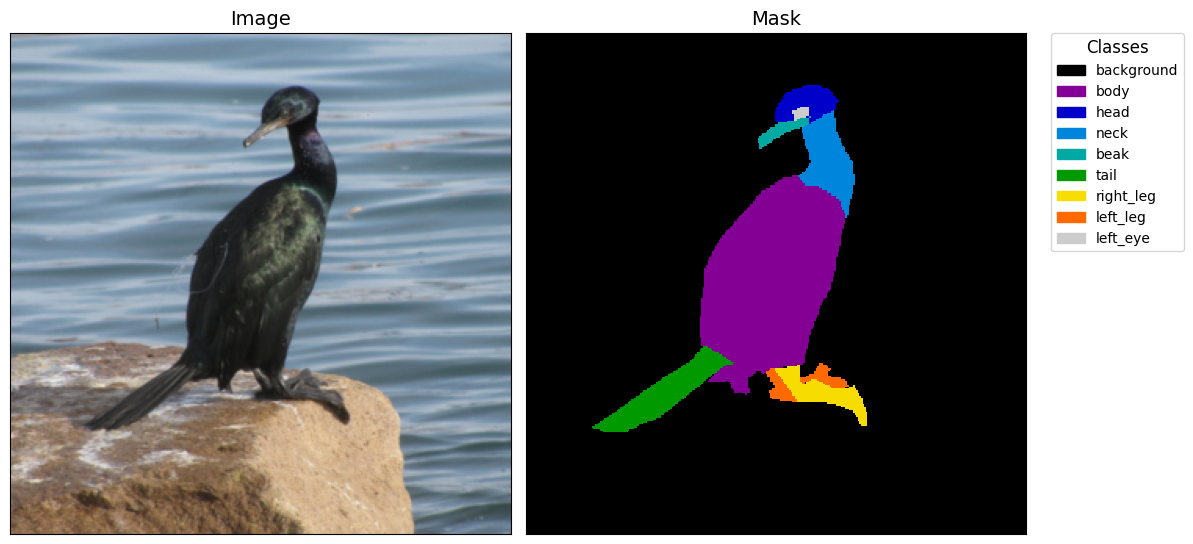

In [7]:
# Get sample image and mask
img, mask = train_set[30]
visualize(image=img, mask=mask)

In [8]:
class CamVidModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )

        # Preprocessing parameters for image normalization
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.number_of_classes = out_classes
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # Loss function for multi-class segmentation
        self.loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

        # Step metrics tracking
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # Normalize image
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image, mask = batch

        # Ensure that image dimensions are correct
        assert image.ndim == 4  # [batch_size, channels, H, W]

        # Ensure the mask is a long (index) tensor
        mask = mask.long()

        # Mask shape
        assert mask.ndim == 3  # [batch_size, H, W]

        # Predict mask logits
        logits_mask = self.forward(image)

        assert (
            logits_mask.shape[1] == self.number_of_classes
        )  # [batch_size, number_of_classes, H, W]

        # Ensure the logits mask is contiguous
        logits_mask = logits_mask.contiguous()

        # Compute loss using multi-class Dice loss (pass original mask, not one-hot encoded)
        loss = self.loss_fn(logits_mask, mask)

        # Apply softmax to get probabilities for multi-class segmentation
        prob_mask = logits_mask.softmax(dim=1)

        # Convert probabilities to predicted class labels
        pred_mask = prob_mask.argmax(dim=1)

        # Compute true positives, false positives, false negatives, and true negatives
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask, mask, mode="multiclass", num_classes=self.number_of_classes
        )

        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # Aggregate step metrics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # Per-image IoU and dataset IoU calculations
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        self.training_step_outputs.clear()

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        self.test_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }

In [9]:
model = CamVidModel(MODEL_NAME, ENCODER_NAME, in_channels=3, out_classes=num_classes)

In [10]:
trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1, devices=[DEVICE_ID])

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [11]:
# run validation dataset
valid_metrics = trainer.validate(model, dataloaders=val_loader, verbose=False)
print(valid_metrics)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Validation: |          | 0/? [00:00<?, ?it/s]

[{'valid_per_image_iou': 0.9181181192398071, 'valid_dataset_iou': 0.9154717922210693}]


In [12]:
# run test dataset
test_metrics = trainer.test(model, dataloaders=test_loader, verbose=False)
print(test_metrics)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Testing: |          | 0/? [00:00<?, ?it/s]

[{'test_per_image_iou': 0.8979275822639465, 'test_dataset_iou': 0.8901450634002686}]


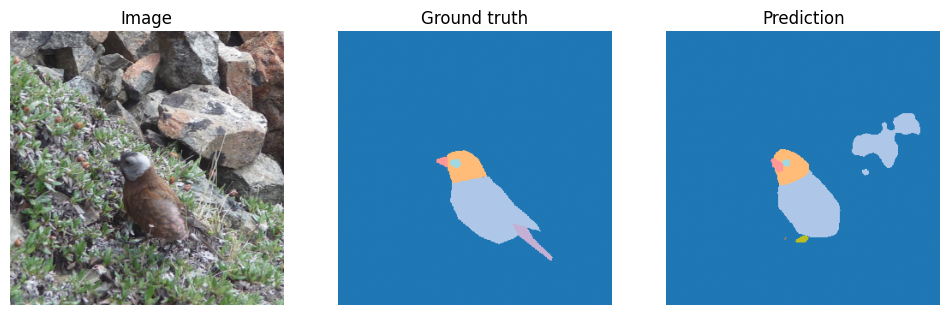

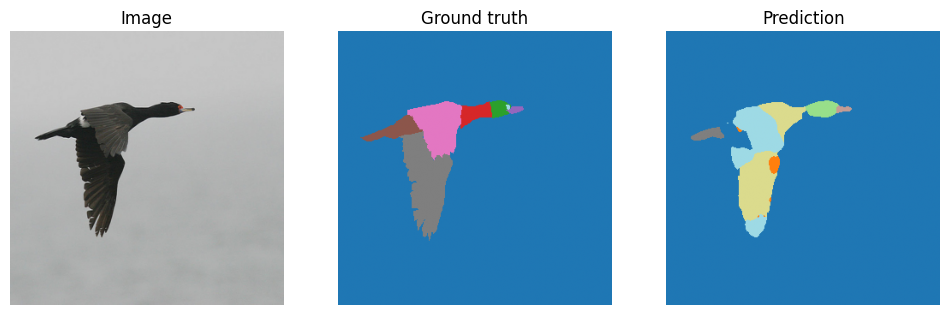

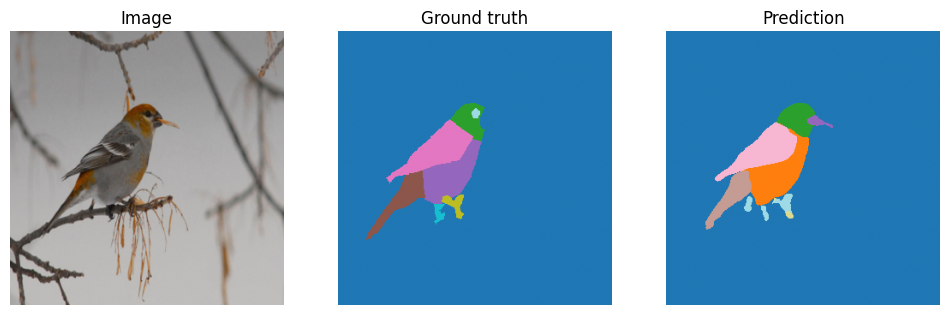

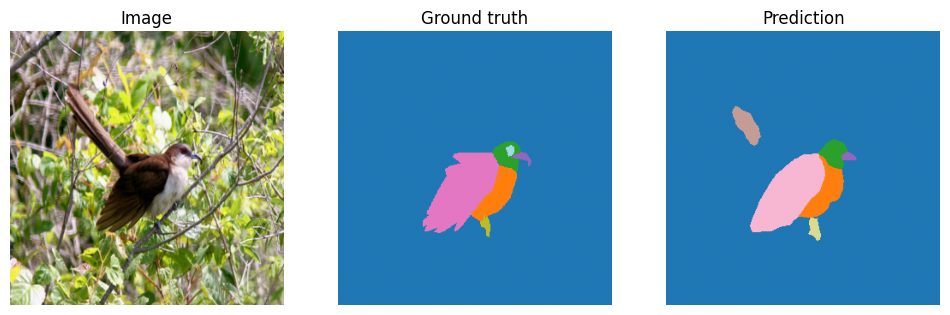

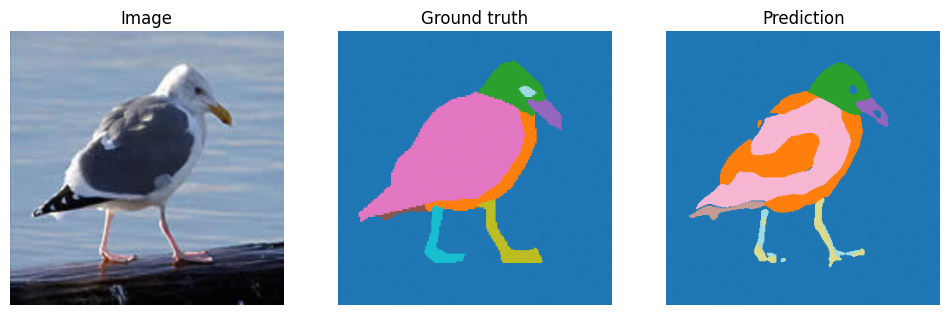

In [13]:
# Fetch a batch from the test loader
images, masks = next(iter(test_loader))

# Switch the model to evaluation mode
with torch.inference_mode():
    model.eval()
    logits = model(images)  # Get raw logits from the model

# Apply softmax to get class probabilities
# Shape: [batch_size, num_classes, H, W]

pr_masks = logits.softmax(dim=1)
# Convert class probabilities to predicted class labels
pr_masks = pr_masks.argmax(dim=1)  # Shape: [batch_size, H, W]

# Visualize a few samples (image, ground truth mask, and predicted mask)
for idx, (image, gt_mask, pr_mask) in enumerate(zip(images, masks, pr_masks)):
    if idx <= 4:  # Visualize first 5 samples
        plt.figure(figsize=(12, 6))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(
            image.cpu().numpy().transpose(1, 2, 0)
        )  # Convert CHW to HWC for plotting
        plt.title("Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.cpu().numpy(), cmap="tab20")  # Visualize ground truth mask
        plt.title("Ground truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().numpy(), cmap="tab20")  # Visualize predicted mask
        plt.title("Prediction")
        plt.axis("off")

        # Show the figure
        plt.show()
    else:
        break